In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
epsilon = 0.01
data = pd.read_csv(f"vectorize_experimentadult_ExpGrad_08-12-2025_14-26-19/results_{epsilon}.csv")

In [14]:
def plot_avg_entropy_expgrad(model,dataset,load_path,save_path):
    fig, ax = plt.subplots(1,1,figsize=(20,10))
    entr1_mean = []
    entr1_std = []
    entr2_mean = []
    entr2_std = []
    entr3_mean = []
    entr3_std = []
    entr4_mean = []
    entr4_std = []
    entr5_mean = []
    entr5_std = []

    epsilons = np.linspace(0.01,0.1,11)
    for i,eps in enumerate(epsilons):
        eps = round(eps,3)

        if not os.path.exists(f"{load_path}/results_{eps}.csv"):
            continue

        data = pd.read_csv(f"{load_path}/results_{eps}.csv")
        entr1 = data["entropy_nodtype"].to_numpy()
        entr2= data["entropy_float16"].to_numpy()
        entr3= data["entropy_float32"].to_numpy()
        entr4= data["entropy_float64"].to_numpy()
        entr5= data["entropy_longdouble"].to_numpy()
        S = data["S"].to_numpy()

        entr1_mean.append(np.mean(entr1))
        entr1_std.append(np.std(entr1))
        entr2_mean.append(np.mean(entr1))
        entr2_std.append(np.std(entr1))
        entr3_mean.append(np.mean(entr1))
        entr3_std.append(np.std(entr1))
        entr4_mean.append(np.mean(entr1))
        entr4_std.append(np.std(entr1))
        entr5_mean.append(np.mean(entr1))
        entr5_std.append(np.std(entr1))
    
    ax.errorbar(epsilons, entr1_mean, yerr=entr1_std,capsize=3, fmt="--o",label="no dtype")
    ax.errorbar(epsilons, entr2_mean, yerr=entr2_std,capsize=3, fmt="--o",label="f16")
    ax.errorbar(epsilons, entr3_mean, yerr=entr3_std,capsize=3, fmt="--o",label="f32")
    ax.errorbar(epsilons, entr4_mean, yerr=entr4_std,capsize=3, fmt="--o",label="f64")
    ax.errorbar(epsilons, entr5_mean, yerr=entr5_std,capsize=3, fmt="--o",label="longdouble")

    ax.set_title("All sens. groups")
    ax.set_xlabel("Gamma")
    ax.set_ylabel("Entropy")
    ax.set_ylim(-0.1,1.1)
    ax.legend()

    #plt.savefig(f"{save_path}/{dataset}_{model}_avg_entropy.pdf")

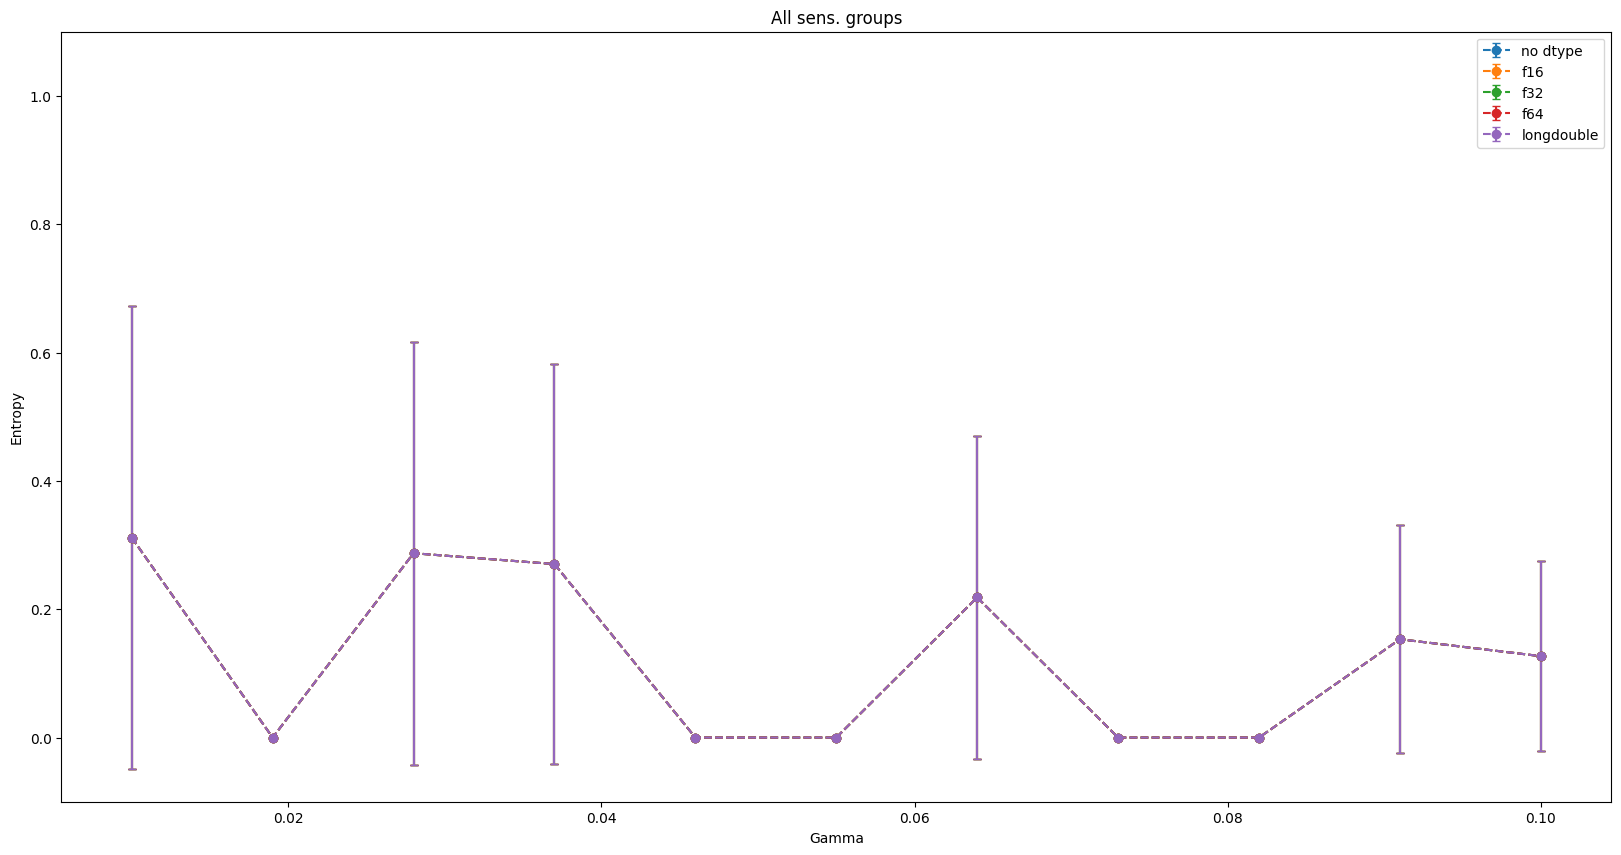

In [15]:
plot_avg_entropy_expgrad("ExpGrad","adult","vectorize_experimentadult_ExpGrad_08-12-2025_14-26-19",".")